In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from transforms import radon
from dflow_func import dflow, animate_iterates
from unet import Unet
from utils import load_checkpoint
import os

/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
shepps = torch.load("data/shepp-logan-dataset-128.pt")["test"]
shepp = shepps[0:1].squeeze()
print(shepp.shape)

torch.Size([128, 128])


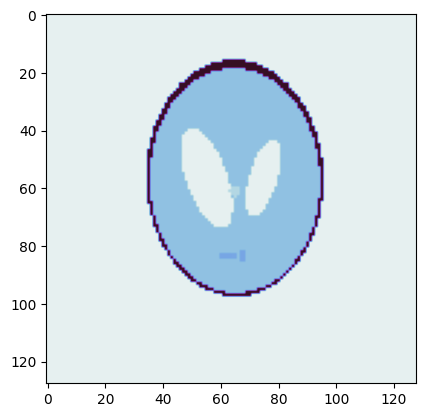

In [3]:
plt.imshow(shepp, cmap=cmocean.cm.dense)

In [4]:

%%capture
im_size = 128
run = "run1"
problem = "shepp-logan"
os.makedirs(f'dflow-radon-metrics/{run}-{problem}', exist_ok=True)
checkpoint_path = f'problems/{problem}/checkpoints/{im_size}x{im_size}/ckp_63000.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# getting normalization constants
train_min, train_max = torch.min(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"]), torch.max(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"])
# match the number of channels to your model
model = Unet(ch=32).to(device)

# ema_model = torch.optim.swa_utils.AveragedModel(
#     model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(0.9999)
# )
_, _, model, _, _, _= load_checkpoint(model=model, path=checkpoint_path)
model.eval()

torch.Size([24, 182])


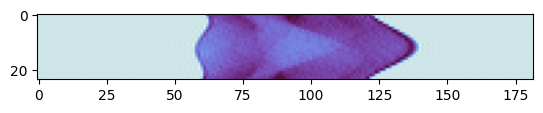

In [11]:
N=24
radon_shepp = radon.radon_transform(shepp, N=N)
print(radon_shepp.shape)
plt.imshow(radon_shepp, cmap=cmocean.cm.dense)


In [ ]:
radon_shepp = radon_shepp.to(device)
reconstructed, metrics, svd_traj, x1_trajectory = dflow(
    max_iter=1,
    optim_steps=1,
    target_cost=0.05,
    patience=20,
    model=model,
    lr=0.1,
    y=radon_shepp.unsqueeze(0).unsqueeze(0),
    train_min=train_min,
    train_max=train_max,
    N=N,
    optimizer="SGD"
)
animate_iterates(x1_trajectory=x1_trajectory, gt=shepp, save=True, run=run, problem=problem, N=N)

TypeError: animate_iterates() got multiple values for argument 'run'

In [ ]:
torch.save(metrics, f'dflow-radon-metrics/{run}-{problem}/N{N}-metrics.pt')